# Analyse de VaR pour un portefeuille

## Portefeuille TSLA / AMD / NVDA

Ce projet calcule la **Value at Risk (VaR)** d'un portefeuille actions par trois méthodes différentes (historique, paramétrique, Monte Carlo), puis valide le résultat par backtesting.

##1. Installation et imports

Installation de `yfinance` (récupération de données boursières) et des librairies de calcul standard.

In [1]:
!pip install yfinance -q
import yfinance as yf
import pandas as pd
import numpy as np

##2. Récupération des données

J'ai choisi trois actions du secteur technologique — Tesla (TSLA), AMD et Nvidia (NVDA) — sur une période de 2 ans (septembre 2024 à septembre 2026). Ces valeurs sont connues pour leur forte volatilité, ce qui permet d'observer des résultats de VaR significatifs et de bien illustrer la méthodologie sur un cas concret plutôt que sur un portefeuille peu risqué.

In [2]:
data = yf.download(["TSLA", "AMD", "NVDA"], start="2024-09-27", end="2026-09-27")
data.head()
close_prices = data["Close"]
close_prices.head()

/tmp/ipykernel_2928/802832411.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(["TSLA", "AMD", "NVDA"], start="2024-09-27", end="2026-09-27")
[*********************100%***********************]  3 of 3 completed


Ticker,AMD,NVDA,TSLA
Date,,,
2024-09-27,164.350006,121.075127,260.459991
2024-09-30,164.080002,121.115021,261.630005
2024-10-01,159.750000,116.686890,258.019989
2024-10-02,159.779999,118.531952,249.020004
2024-10-03,162.850006,122.521248,240.660004


##3. Calcul des rendements

On calcule le rendement journalier de chaque action avec la formule (Prix_jour - Prix_veille) / Prix_veille, exprimé en pourcentage plutôt qu'en variation absolue. Cela rend les actions comparables entre elles (une variation de 5$ n'a pas le même poids selon le niveau du prix) et donne une série statistiquement stable (stationnaire), contrairement aux prix bruts qui suivent une tendance dans le temps — c'est cette propriété qui permet de calculer ensuite une moyenne, un écart-type et une VaR.

In [3]:
returns = close_prices.pct_change().dropna()
returns.head()
returns.describe()


Ticker,AMD,NVDA,TSLA
count,499.000000,499.000000,499.000000
mean,0.003474,0.001630,0.001416
std,0.039891,0.027806,0.037696
min,-0.173144,-0.169682,-0.154262
25%,-0.018913,-0.013561,-0.019283
50%,0.001506,0.002368,0.000159
75%,0.022059,0.017686,0.022740
max,0.238205,0.187227,0.226900


##4. Construction du portefeuille

Le portefeuille est construit avec une pondération égale entre les trois actions (1/3 chacune), un choix simple qui permet de se concentrer sur la méthodologie de calcul de la VaR plutôt que sur un problème d'allocation optimale. Cette pondération suppose implicitement un rééquilibrage quotidien du portefeuille à 1/3-1/3-1/3 : en pratique, sans rééquilibrage, les poids dériveraient progressivement en fonction de la performance relative de chaque action.

In [4]:
weights = np.array([1/3, 1/3, 1/3])
portfolio_returns = returns.dot(weights)
portfolio_returns.head()

,0
Date,
2024-09-30,0.001060
2024-10-01,-0.025583
2024-10-02,-0.006294
2024-10-03,0.006433
2024-10-04,0.035141


##5. VaR historique

La VaR historique consiste à prendre directement le 5e percentile des rendements observés du portefeuille : c'est le seuil en dessous duquel se trouvent les 5% pires jours de l'historique. Concrètement, on estime qu'il y a 5% de chances que le portefeuille perde plus que cette valeur sur une journée, sans faire d'hypothèse sur la forme de la distribution des rendements.

In [5]:
var_95 = np.percentile(portfolio_returns, 5)
print(f"VaR 95% (1 jour) : {var_95:.2%}")
print(f"En euros sur 100 000 € : {var_95 * 100000:,.0f} €")


VaR 95% (1 jour) : -4.26%
En euros sur 100 000 € : -4,256 €


##6. VaR paramétrique

Ici on suppose que les rendements du portefeuille suivent une loi normale, et on calcule le seuil avec sa moyenne (μ) et son écart-type (σ) : `VaR = μ + z × σ`. Le terme z correspond au point de la loi normale sous lequel se trouvent 5% des cas (z ≈ -1,645 pour un seuil à 95%).

In [6]:
from scipy.stats import norm

mu = portfolio_returns.mean()
sigma = portfolio_returns.std()
z = norm.ppf(0.05)

var_95_param = mu + z * sigma
print(f"z (95%) : {z:.3f}")
print(f"VaR paramétrique 95% (1 jour) : {var_95_param:.2%}")
print(f"En euros sur 100 000 € : {var_95_param * 100000:,.0f} €")

z (95%) : -1.645
VaR paramétrique 95% (1 jour) : -4.41%
En euros sur 100 000 € : -4,408 €


## 6bis. Comparaison à 99% : effet des queues épaisses

L'écart entre VaR historique et paramétrique reste faible à 95% (-4,26% vs -4,41%), mais se creuse nettement à 99% (-7,40% vs -6,32%). Cela illustre concrètement la limite de l'hypothèse de loi normale : les vrais rendements ont des "queues épaisses" (fat tails), c'est-à-dire que les pertes extrêmes sont plus fréquentes que ne le prévoit une distribution normale parfaite.

In [7]:
var_99_hist = np.percentile(portfolio_returns, 1)
var_99_param = mu + norm.ppf(0.01) * sigma
print(f"VaR 99% historique  : {var_99_hist:.2%}")
print(f"VaR 99% paramétrique : {var_99_param:.2%}")

VaR 99% historique  : -7.40%
VaR 99% paramétrique : -6.32%


7. VaR Monte Carlo

La VaR Monte Carlo simule 100 000 scénarios de rendements possibles à partir de la moyenne et de la matrice de covariance des 3 actions (qui capture le fait qu'elles ne bougent pas indépendamment), puis prend le 5e percentile des rendements de portefeuille simulés. Une seconde version utilise un bootstrap : au lieu de simuler depuis une loi normale théorique, on ré-échantillonne au hasard parmi les vrais rendements observés, ce qui capture mieux les queues épaisses de la distribution réelle.

In [8]:
mean_vec = returns.mean().values
cov_matrix = returns.cov().values

np.random.seed(42)
n_sims = 100_000
sim_returns = np.random.multivariate_normal(mean_vec, cov_matrix, n_sims)
sim_portfolio = sim_returns.dot(weights)

var_95_mc = np.percentile(sim_portfolio, 5)
print(f"VaR Monte Carlo 95% : {var_95_mc:.2%}")
np.random.seed(42)
n_sims = 100_000
sampled_returns = returns.sample(n=n_sims, replace=True).values
sim_portfolio_boot = sampled_returns.dot(weights)
var_95_boot = np.percentile(sim_portfolio_boot, 5)
print(f"VaR Monte Carlo (bootstrap historique) 95% : {var_95_boot:.2%}")

VaR Monte Carlo 95% : -4.42%
VaR Monte Carlo (bootstrap historique) 95% : -4.25%


8. Backtesting

Pour vérifier que la VaR est fiable, on compte le nombre de fois où le rendement réel du portefeuille a dépassé (à la baisse) le seuil de VaR historique à 95%. Si le modèle est bien calibré, ce taux de dépassement doit être proche de 5% — un taux beaucoup plus élevé indiquerait que la VaR sous-estime le risque réel.

In [9]:
breaches = portfolio_returns < var_95
n_breaches = breaches.sum()
n_days = len(portfolio_returns)
breach_rate = n_breaches / n_days
print(f"Dépassements : {n_breaches} sur {n_days} jours ({breach_rate:.2%})")
print(f"Taux attendu : 5.00%")

Dépassements : 25 sur 499 jours (5.01%)
Taux attendu : 5.00%


9. Visualisation

Ce graphique superpose trois éléments : la courbe des rendements journaliers du portefeuille, la ligne de seuil de la VaR historique à 95%, et les points rouges marquant chaque dépassement. On observe plusieurs pics de rendement, ainsi que des dépassements ponctuels du seuil, mais leur fréquence reste cohérente avec les 5% attendus par construction.

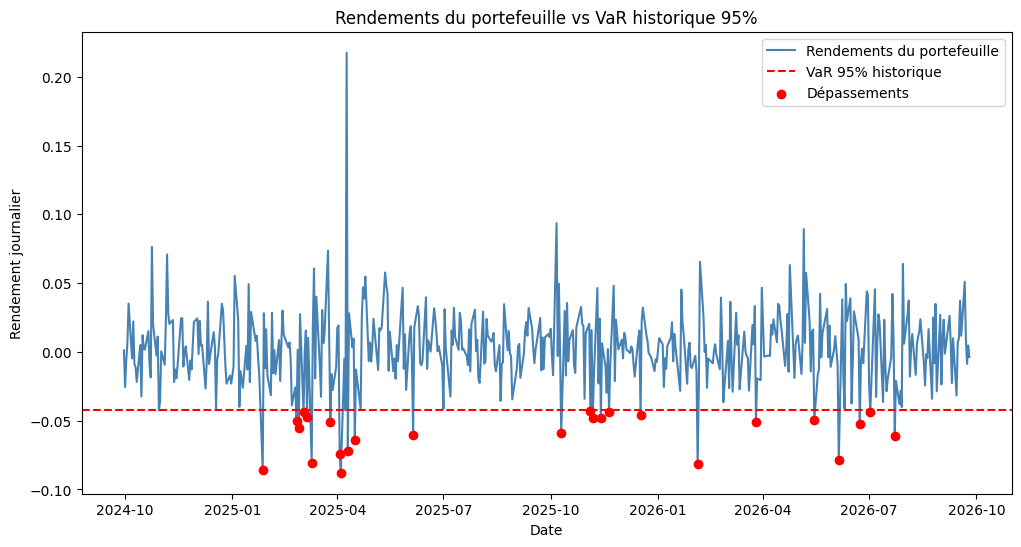

In [10]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.plot(portfolio_returns.index, portfolio_returns, label="Rendements du portefeuille", color="steelblue")
plt.axhline(y=var_95, color="red", linestyle="--", label="VaR 95% historique")
plt.scatter(portfolio_returns.index[breaches], portfolio_returns[breaches], color="red", zorder=5, label="Dépassements")
plt.title("Rendements du portefeuille vs VaR historique 95%")
plt.xlabel("Date")
plt.ylabel("Rendement journalier")
plt.legend()
plt.show()

## Conclusion

| Méthode | VaR 95% (1 jour) | VaR 99% (1 jour) |
|---|---|---|
| Historique | -4.26% | -7.40% |
| Paramétrique | -4.41% | -6.32% |
| Monte Carlo (normal) | -4.42% | — |
| Monte Carlo (bootstrap) | -4.25% | — |

**Backtesting** : le taux de dépassement observé (5.01% sur 499 jours) correspond quasiment exactement au seuil théorique de 5%, confirmant que la VaR historique est bien calibrée sur cette période.

**Synthèse** : les quatre méthodes convergent à 95% (écart maximal de 0,2 point), ce qui valide la cohérence de l'implémentation. L'écart se creuse en revanche à 99% (-7.40% contre -6.32%), illustrant une limite connue de l'hypothèse de loi normale : elle sous-estime la fréquence des pertes extrêmes (*fat tails*). Ce projet montre ainsi non seulement la capacité à implémenter plusieurs méthodes de calcul de VaR, mais aussi à en identifier les limites et à les valider empiriquement par backtesting — une démarche proche de ce qu'attend une fonction risque sur un desk.

In [11]:
close_prices.to_csv("prix_actions.csv")
returns.to_csv("rendements.csv")